# IoT Farm Deodorization Data-to-RL Workflow

This notebook is organized into parts: data ingestion, cleaning, simulation, scenario checks, RL environment setup, training, evaluation, and optional online updates.


## 1. Convert Raw JSON to Wide CSV

Transform per-sensor JSON data retrieved from ThingsBoard into timestamp-aligned wide tables for each device.

Outputs `pi-1-data.csv` and `pi-2-data.csv`.


In [135]:
from pathlib import Path
from typing import TypeAlias
import json
import pandas as pd

SensorRecord: TypeAlias = dict[str, int | str]
SensorPayload: TypeAlias = dict[str, list[SensorRecord]]
EXPECTED_SENSOR_COLUMNS: list[str] = [
    "aqi-1",
    "aqi-2",
    "aqi-3",
    "aqi-4",
    "aqi-5",
    "co2-1",
    "co2-2",
    "co2-3",
    "co2-4",
    "co2-5",
    "humi-1",
    "humi-2",
    "humi-3",
    "humi-4",
    "humi-5",
    "temp-1",
    "temp-2",
    "temp-3",
    "temp-4",
    "temp-5",
    "tvoc-1",
    "tvoc-2",
    "tvoc-3",
    "tvoc-4",
    "tvoc-5",
]
PI2_DROP_COLUMNS: list[str] = ["aqi-5", "co2-5", "humi-5", "temp-5", "tvoc-5"]

# Workspace root containing JSON inputs.
BASE_DIR: Path = Path.cwd()
INPUT_FILES: list[Path] = [BASE_DIR / "pi-1-data.json", BASE_DIR / "pi-2-data.json"]


def json_to_wide_dataframe(json_path: Path) -> pd.DataFrame:
    """Convert one sensor JSON file into a wide DataFrame keyed by timestamp."""
    with json_path.open("r", encoding="utf-8") as f:
        payload: SensorPayload = json.load(f)

    long_frames: list[pd.DataFrame] = []

    for sensor_name, records in payload.items():
        if not isinstance(records, list):
            continue

        sensor_df = pd.DataFrame(records)
        if (
            sensor_df.empty
            or "ts" not in sensor_df.columns
            or "value" not in sensor_df.columns
        ):
            continue

        sensor_df = sensor_df[["ts", "value"]].rename(
            columns={"ts": "timestamp", "value": "value"}
        )
        sensor_df["value"] = pd.to_numeric(
            sensor_df["value"].replace("N/A", pd.NA), errors="coerce"
        )
        sensor_df["sensor"] = sensor_name
        long_frames.append(sensor_df)

    if not long_frames:
        return pd.DataFrame(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])

    long_df = pd.concat(long_frames, ignore_index=True)
    wide_df = long_df.pivot_table(
        index="timestamp", columns="sensor", values="value", aggfunc="last"
    )
    wide_df = wide_df.reset_index()
    wide_df.columns.name = None
    wide_df["timestamp"] = pd.to_numeric(wide_df["timestamp"], errors="coerce").astype(
        "Int64"
    )
    wide_df = wide_df.reindex(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])
    wide_df = wide_df.sort_values("timestamp", na_position="last").reset_index(
        drop=True
    )
    return wide_df


summaries: list[dict[str, int | str]] = []
for input_path in INPUT_FILES:
    if not input_path.exists():
        print(f"Skipping missing file: {input_path.name}")
        continue

    df = json_to_wide_dataframe(input_path)

    # Sensor-5 on pi-2 is known failed during this time window.
    if input_path.name.startswith("pi-2"):
        df = df.drop(columns=PI2_DROP_COLUMNS, errors="ignore")

    output_path = input_path.with_suffix(".csv")
    df.to_csv(output_path, index=False)

    summaries.append(
        {
            "input": input_path.name,
            "output": output_path.name,
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
        }
    )

summary_df = pd.DataFrame(summaries)
summary_df

,input,output,rows,columns
0,pi-1-data.json,pi-1-data.csv,4861,26
1,pi-2-data.json,pi-2-data.csv,4838,21


## 2. Clean, Aggregate, and Plot 5-Min Data

Denoise sensor spikes, resample to 5-minute buckets, and aggregate across sensor locations.

Outputs cleaned files (e.g., `pi-1-data-clean-5min.csv`) and quick QA plots for TVOC, CO2, humidity, temperature, and valid-sensor count.


In [136]:
from typing import Final

RESAMPLE_RULE: Final[str] = "5min"
SHORT_GAP_MAX: Final[int] = 2  # <=10 minutes
MEDIUM_GAP_MAX: Final[int] = 12  # <=60 minutes

FAMILY_SENSOR_COLUMNS: dict[str, list[str]] = {
    "tvoc": ["tvoc-1", "tvoc-2", "tvoc-3", "tvoc-4", "tvoc-5"],
    "co2": ["co2-1", "co2-2", "co2-3", "co2-4", "co2-5"],
    "humidity": ["humi-1", "humi-2", "humi-3", "humi-4", "humi-5"],
    "temp": ["temp-1", "temp-2", "temp-3", "temp-4", "temp-5"],
}


def _sensor_family(column_name: str) -> str:
    if "-" in column_name:
        return column_name.split("-", 1)[0]
    return column_name


def _mark_delta_glitches(
    df_in: pd.DataFrame, value_cols: list[str], z_threshold: float = 6.0
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Mark sample as glitch when jump from previous sample is abnormally high."""
    df_out = df_in.copy()
    glitch_counts: dict[str, int] = {}

    for col in value_cols:
        family = _sensor_family(col)
        s = pd.to_numeric(df_out[col], errors="coerce")
        abs_delta = s.diff().abs()

        delta_median = abs_delta.median(skipna=True)
        delta_mad = (abs_delta - delta_median).abs().median(skipna=True)

        if pd.isna(delta_median):
            glitch_counts[col] = 0
            continue

        if pd.isna(delta_mad) or delta_mad == 0:
            jump_limit = float(delta_median) * 3.0
        else:
            jump_limit = float(delta_median) + z_threshold * 1.4826 * float(delta_mad)

        glitch_mask = abs_delta > jump_limit

        glitch_counts[col] = int(glitch_mask.sum())
        df_out.loc[glitch_mask, col] = pd.NA

    return df_out, glitch_counts


def _apply_selective_gap_fill(
    series_in: pd.Series,
) -> tuple[pd.Series, pd.Series]:
    """Short gaps: ffill, medium gaps: linear interpolate, long gaps: keep missing for drop."""
    s = series_in.copy()
    missing_mask = s.isna()
    group_id = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()
    missing_run_length = missing_mask.groupby(group_id).transform("sum")

    short_gap_mask = missing_mask & (missing_run_length <= SHORT_GAP_MAX)
    medium_gap_mask = (
        missing_mask
        & (missing_run_length > SHORT_GAP_MAX)
        & (missing_run_length <= MEDIUM_GAP_MAX)
    )
    long_gap_mask = missing_mask & (missing_run_length > MEDIUM_GAP_MAX)

    s_ffill = s.ffill(limit=SHORT_GAP_MAX)
    s_interp = s.interpolate(
        method="linear", limit=MEDIUM_GAP_MAX, limit_direction="both"
    )

    s_out = s.copy()
    s_out.loc[short_gap_mask] = s_ffill.loc[short_gap_mask]
    s_out.loc[medium_gap_mask] = s_interp.loc[medium_gap_mask]
    return s_out, long_gap_mask


def clean_align_5min(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    df = df_raw.copy()

    # Parse and index time.
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["timestamp"]).copy()
    df["time"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.drop(columns=["timestamp"]).set_index("time").sort_index()

    # Keep last if duplicate timestamps present.
    before_dupes = len(df)
    df = df[~df.index.duplicated(keep="last")]
    removed_dupes = before_dupes - len(df)

    sensor_cols = [
        c for cols in FAMILY_SENSOR_COLUMNS.values() for c in cols if c in df.columns
    ]

    # Glitch cleanup from abnormal sample-to-sample jumps.
    df, delta_counts = _mark_delta_glitches(df, sensor_cols)

    # Resample to 5-minute buckets at sensor-channel level first (robust median).
    sensor_5m = df[sensor_cols].resample(RESAMPLE_RULE).median(numeric_only=True)

    # Robust aggregation per variable using median across available sensor locations.
    final_df = pd.DataFrame(index=sensor_5m.index)
    for out_col, source_cols in FAMILY_SENSOR_COLUMNS.items():
        active_cols = [c for c in source_cols if c in sensor_5m.columns]
        if active_cols:
            final_df[out_col] = sensor_5m[active_cols].median(axis=1, skipna=True)
        else:
            final_df[out_col] = pd.NA

    # Count working locations from whatever sensors actually exist in this dataset.
    available_locations = sorted(
        {
            int(c.split("-", 1)[1])
            for c in sensor_cols
            if "-" in c and c.split("-", 1)[1].isdigit()
        }
    )

    working_location_flags: list[pd.Series] = []
    for loc in available_locations:
        loc_cols = [f"tvoc-{loc}", f"co2-{loc}", f"humi-{loc}", f"temp-{loc}"]
        active_loc_cols = [c for c in loc_cols if c in sensor_5m.columns]
        if active_loc_cols:
            working_location_flags.append(
                sensor_5m[active_loc_cols].notna().any(axis=1)
            )

    if working_location_flags:
        valid_sensor_count = (
            pd.concat(working_location_flags, axis=1).sum(axis=1).astype(int)
        )
    else:
        valid_sensor_count = pd.Series(0, index=final_df.index, dtype=int)
    final_df["valid_sensor_count"] = valid_sensor_count

    # Selective missing-data handling by variable.
    long_gap_any = pd.Series(False, index=final_df.index)
    for col in ["tvoc", "co2", "humidity", "temp"]:
        final_df[col], long_gap_mask = _apply_selective_gap_fill(
            pd.to_numeric(final_df[col], errors="coerce")
        )
        long_gap_any = long_gap_any | long_gap_mask

    rows_before_long_drop = len(final_df)
    final_df = final_df.loc[~long_gap_any].copy()
    rows_dropped_long_gaps = rows_before_long_drop - len(final_df)

    final_df = final_df.reset_index()

    report = {
        "rows_in": int(len(df_raw)),
        "rows_5min": int(len(final_df)),
        "rows_with_le_2_sensors_working": int(
            (final_df["valid_sensor_count"] <= 2).sum()
        ),
        "dupe_timestamps_removed": int(removed_dupes),
        "delta_glitches_marked_total": int(sum(delta_counts.values())),
        "rows_dropped_long_gaps": int(rows_dropped_long_gaps),
        "missing_after_fill_total": int(
            final_df[["tvoc", "co2", "humidity", "temp"]].isna().sum().sum()
        ),
    }
    return final_df, report


cleaned_reports: list[dict[str, int | str]] = []
cleaned_frames: dict[str, pd.DataFrame] = {}

for input_name in ["pi-1-data.csv", "pi-2-data.csv"]:
    input_path = BASE_DIR / input_name
    if not input_path.exists():
        print(f"Skipping missing CSV: {input_name}")
        continue

    raw_df = pd.read_csv(input_path)
    cleaned_df, stats = clean_align_5min(raw_df)
    cleaned_frames[input_name] = cleaned_df

    out_name = input_name.replace(".csv", "-clean-5min.csv")
    out_path = BASE_DIR / out_name
    cleaned_df.to_csv(out_path, index=False)

    cleaned_reports.append(
        {
            "input": input_name,
            "output": out_name,
            **stats,
        }
    )

clean_report_df = pd.DataFrame(cleaned_reports)
clean_report_df

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,1869,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,1600,0,0


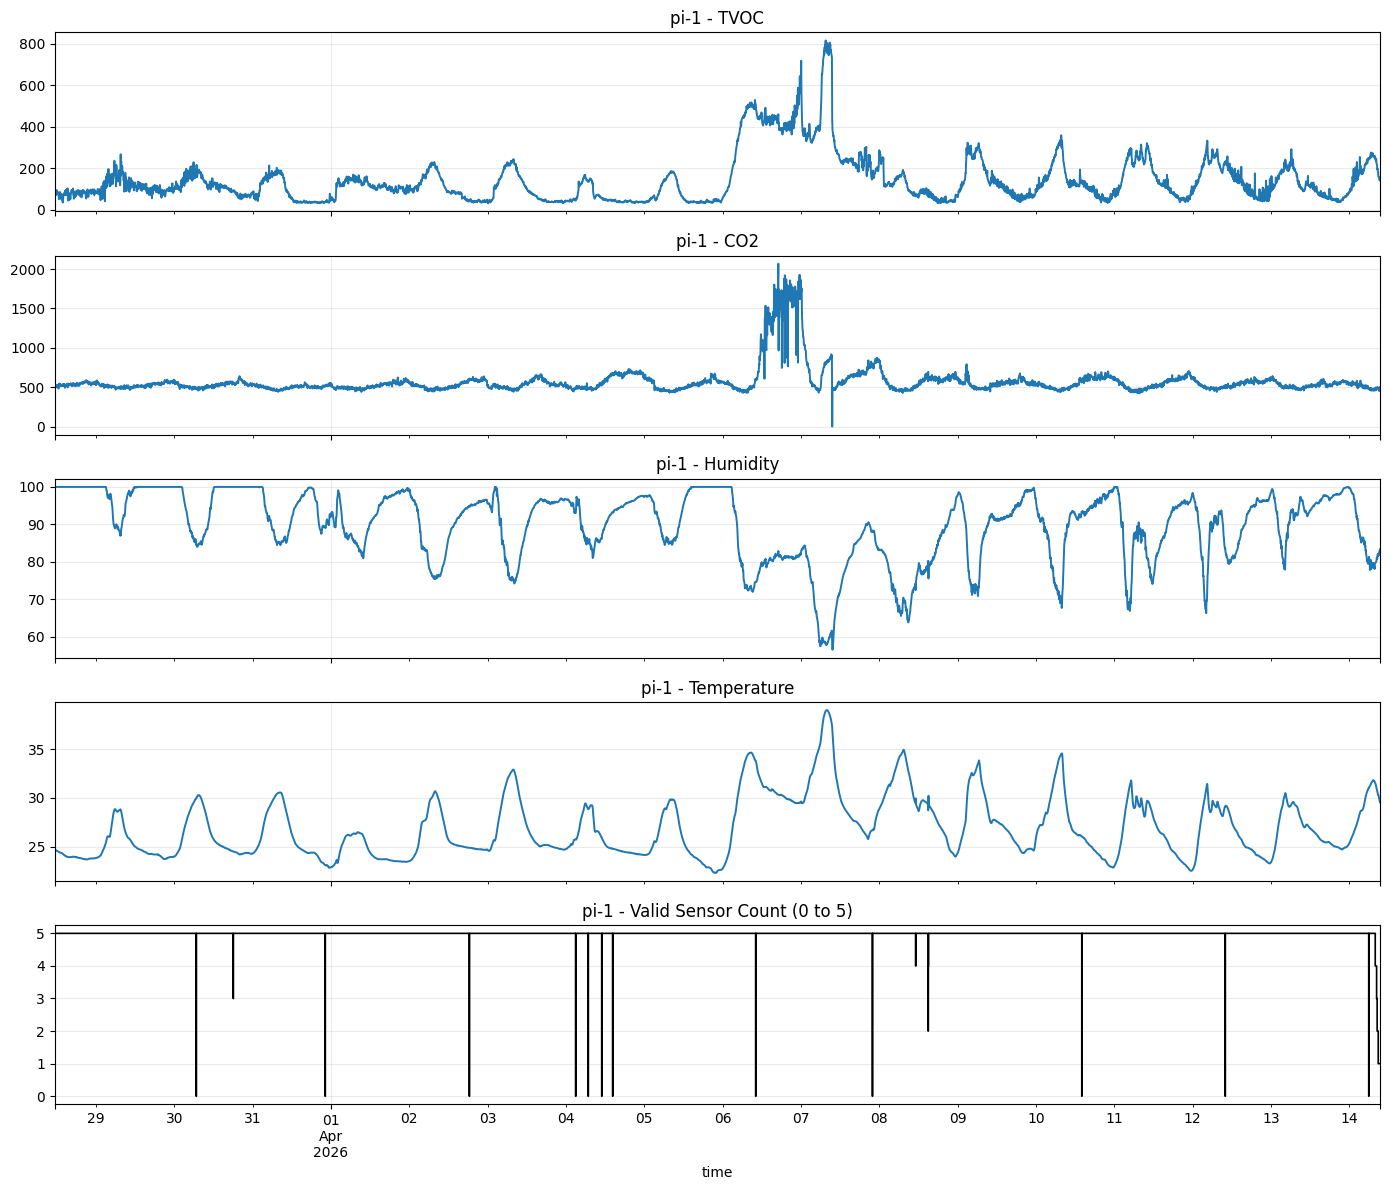

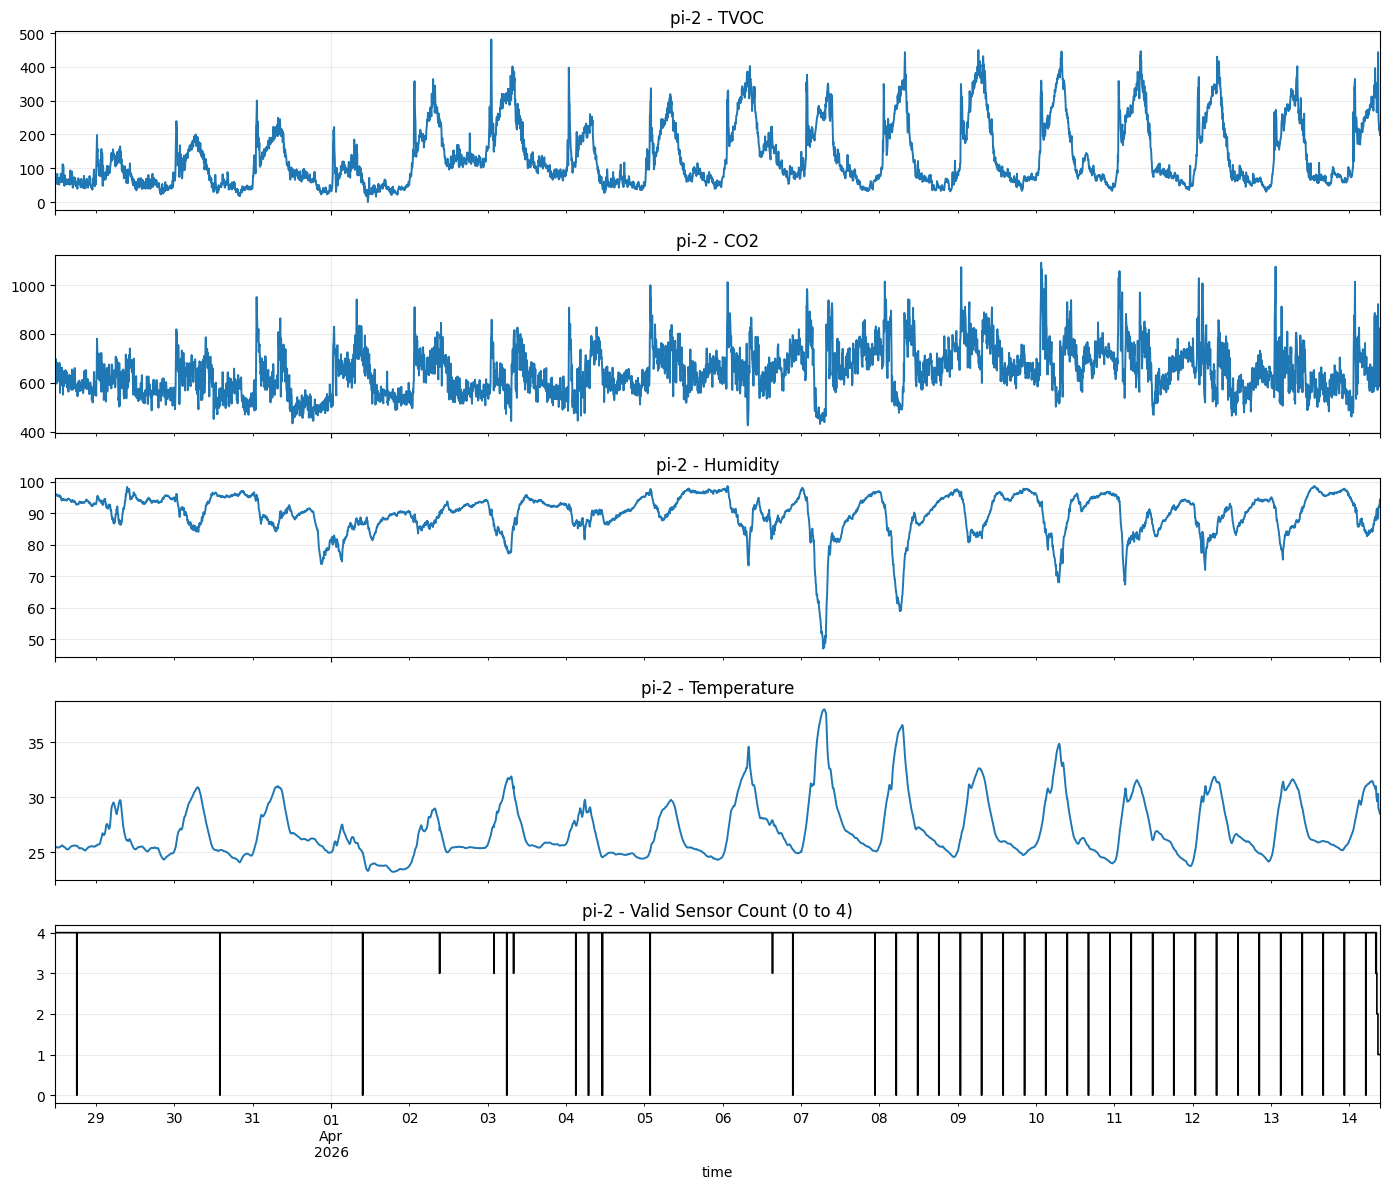

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


In [129]:
import matplotlib.pyplot as plt


def plot_cleaned_dataset(df: pd.DataFrame, title_prefix: str) -> None:
    plot_df = df.copy()
    plot_df["time"] = pd.to_datetime(plot_df["time"], utc=True)
    plot_df = plot_df.set_index("time")

    _, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

    for ax, col, label in [
        (axes[0], "tvoc", "TVOC"),
        (axes[1], "co2", "CO2"),
        (axes[2], "humidity", "Humidity"),
        (axes[3], "temp", "Temperature"),
    ]:
        if col in plot_df.columns:
            plot_df[col].plot(ax=ax, linewidth=1.4)
        ax.set_title(f"{title_prefix} - {label}")
        ax.grid(alpha=0.25)

    max_valid = (
        int(plot_df["valid_sensor_count"].max())
        if "valid_sensor_count" in plot_df.columns
        else 0
    )
    if "valid_sensor_count" in plot_df.columns:
        plot_df["valid_sensor_count"].plot(
            ax=axes[4], linewidth=1.2, color="black", drawstyle="steps-mid"
        )
    axes[4].set_title(f"{title_prefix} - Valid Sensor Count (0 to {max_valid})")
    axes[4].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


for input_name, cleaned_df in cleaned_frames.items():
    prefix = input_name.replace("-data.csv", "").replace(".csv", "")
    plot_cleaned_dataset(cleaned_df, title_prefix=prefix)

clean_report_df

In [130]:
# Calculate rolling standard deviation on numeric columns only.
for input_name, cleaned_df in cleaned_frames.items():
    print(f"Rolling std for {input_name}:")
    window = 6  # 30 minutes at 5-minute intervals
    numeric_cleaned_df = cleaned_df.select_dtypes(include=["number"])
    summary = pd.DataFrame(
        {
            "avg_rolling_std": numeric_cleaned_df.rolling(window=window).std().mean(),
            "mad": numeric_cleaned_df.diff().abs().mean(),
        }
    )
    print(summary)
    print(f"Describe for {input_name}:")
    print(numeric_cleaned_df.describe())

Rolling std for pi-1-data.csv:
                    avg_rolling_std        mad
tvoc                      10.016281   9.681240
co2                       20.396783  21.835591
humidity                   0.456063   0.310105
temp                       0.109694   0.059754
valid_sensor_count         0.035126   0.027915
Describe for pi-1-data.csv:
              tvoc          co2     humidity         temp  valid_sensor_count
count  4873.000000  4873.000000  4873.000000  4873.000000         4873.000000
mean    141.771188   573.277037    89.957087    26.908877            4.976195
std     116.206181   186.887233     9.137619     3.073601            0.311664
min      30.000000     0.000000    56.590000    22.280000            0.000000
25%      63.000000   495.000000    84.430000    24.490000            5.000000
50%     110.000000   530.000000    92.370000    26.060000            5.000000
75%     177.000000   580.000000    97.370000    29.090000            5.000000
max     815.000000  2069.000000   1

In [131]:
import numpy as np
import pandas as pd


def one_step_abs_diff(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.diff().abs().dropna()


def positive_excess(x: pd.Series, target: float) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return (x - target).clip(lower=0.0)


# Build one combined calibration frame if you have multiple cleaned datasets.
all_frames = []
for name, df in cleaned_frames.items():
    tmp = df.copy()
    tmp["source"] = name
    all_frames.append(tmp)
cal_df = pd.concat(all_frames, ignore_index=True)

# Progress scales: typical one-step changes.
tvoc_progress_norm = one_step_abs_diff(cal_df["tvoc"]).median()
co2_progress_norm = one_step_abs_diff(cal_df["co2"]).median()

# Excess scales: typical positive violations above target.
tvoc_excess_norm = positive_excess(cal_df["tvoc"], 50.0).quantile(0.75)
co2_excess_norm = positive_excess(cal_df["co2"], 400.0).quantile(0.75)
rh_excess_norm = positive_excess(cal_df["humidity"], 90.0).quantile(0.75)

# Cold excess needs temperature-first logic.
cold_excess_norm = positive_excess(18.0 - cal_df["temp"], 0.0).quantile(0.75)
print(pd.to_numeric(cal_df["temp"], errors="coerce").dropna().describe())

# THI excess norm from the derived THI series.
thi = (
    (0.8 * cal_df["temp"])
    + ((cal_df["humidity"] / 100.0) * (cal_df["temp"] - 14.4))
    + 46.4
)
thi_excess_norm = positive_excess(thi, 73.0).quantile(0.75)

fallbacks = {
    "TVOC_PROGRESS_NORM": tvoc_progress_norm,
    "TVOC_EXCESS_NORM": tvoc_excess_norm,
    "CO2_PROGRESS_NORM": co2_progress_norm,
    "CO2_EXCESS_NORM": co2_excess_norm,
    "THI_EXCESS_NORM": thi_excess_norm,
    "RH_EXCESS_NORM": rh_excess_norm,
    "COLD_EXCESS_NORM": cold_excess_norm,
}

for k, v in fallbacks.items():
    print(f"{k:>18s} = {v:.4f}")

count    9747.000000
mean       26.987498
std         2.851529
min        22.280000
25%        24.890000
50%        26.085000
75%        28.890000
max        39.030000
Name: temp, dtype: float64
TVOC_PROGRESS_NORM = 6.5000
  TVOC_EXCESS_NORM = 136.0000
 CO2_PROGRESS_NORM = 19.0000
   CO2_EXCESS_NORM = 260.5000
   THI_EXCESS_NORM = 8.9526
    RH_EXCESS_NORM = 5.7350
  COLD_EXCESS_NORM = 0.0000


In [132]:
# Observation normalization constants derived from cleaned sensor data.
# Uses p1/p99 to cover realistic range without sensitivity to spikes.

_obs_tvoc = pd.to_numeric(cal_df["tvoc"], errors="coerce").dropna()
_obs_co2 = pd.to_numeric(cal_df["co2"], errors="coerce").dropna()
_obs_temp = pd.to_numeric(cal_df["temp"], errors="coerce").dropna()
_obs_rh = pd.to_numeric(cal_df["humidity"], errors="coerce").dropna()

TVOC_OBS_DIVISOR = float(_obs_tvoc.quantile(0.99))
CO2_OBS_DIVISOR = float(_obs_co2.quantile(0.99))
TEMP_OBS_DIVISOR = float(_obs_temp.quantile(0.99))
RH_OBS_MIN = float(_obs_rh.quantile(0.01))
RH_OBS_SPAN = float(_obs_rh.quantile(0.99)) - RH_OBS_MIN

for name, val in [
    ("TVOC_OBS_DIVISOR", TVOC_OBS_DIVISOR),
    ("CO2_OBS_DIVISOR", CO2_OBS_DIVISOR),
    ("TEMP_OBS_DIVISOR", TEMP_OBS_DIVISOR),
    ("RH_OBS_MIN", RH_OBS_MIN),
    ("RH_OBS_SPAN", RH_OBS_SPAN),
]:
    print(f"{name:>18s} = {val:.4f}")

  TVOC_OBS_DIVISOR = 484.5400
   CO2_OBS_DIVISOR = 1411.4800
  TEMP_OBS_DIVISOR = 35.8051
        RH_OBS_MIN = 61.6646
       RH_OBS_SPAN = 38.3354


## 3. Build Hybrid reduced-order Simulator and Scenario Checks


**Simulation Model scope**

The simulator is a hybrid reduced-order model. The recorded sensor series is used as the counterfactual baseline trajectory under no spray intervention. Spray actions are applied as short-duration perturbations on top of this baseline, rather than replacing the underlying observed dynamics.

The exact deodorant–TVOC dose-response curve is unknown since the underlying mechanisms are complex and depends on factors such as deodorant chemical properties, but the simulator assumes monotone nonlinear diminishing returns with respect to spray concentration. The chosen exponential saturation form is used only as a compact empirical representation of that assumption.

To summarize the modeling assumptions:

- The baseline data are treated as the no-intervention trajectory.
- action = 0 means no spray, so temperature, humidity, and TVOC follow the baseline plus noise only.
- Any nonzero action means one spray event with fixed total liquid volume/mass; the action level changes the active formulation concentration, not the sprayed water mass.
- Other spray factors such as droplet size, nozzle pattern, aerosol settling, spray placement, etc. are assumed such that a spray action only affects the next 5-minute interval for TVOC.
- Temperature and humidity are updated using a reduced psychrometric approximation, not a full condensation/CFD model.
- RH is clipped to [0, 100], and values near saturation are snapped to 100% for numerical stability.
- CO2 is not spray-driven since little to no literature exists on its response to spray interventions; it remains baseline plus noise.


**Temperature**

Spray-induced cooling is approximated from latent heat transfer using a lumped air-mass energy balance. This is a first-order estimate intended to capture the immediate thermal effect of water evaporation under fixed room geometry and fixed spray volume.

We estimate spray-induced cooling from latent heat transfer:

$$
\Delta T \approx \frac{m_{\text{water}}\,L}{m_{\text{air}}\,c_p}
\approx
\frac{1\,\text{kg}\times 2450\,\text{kJ/kg}}{1440\,\text{kg}\times 1.005\,\text{kJ/(kg * K)}}
\approx 1.7^\circ\text{C}
$$

with:

- $m_{\text{water}} = 1\,\text{kg}$ (1 L spray, assuming $\rho\approx1\,\text{kg/L}$)
- $L \approx 2450\text{kJ/kg}$ (latent heat of vaporization)
- $m_{\text{air}} \approx 1411\,\text{kg}$ (for $400\,\text{m}^2 \times 3\,\text{m}$ volume and $\rho_{\text{air}}\approx1.176\,\text{kg/m}^3$)
- $c_p \approx 1.005\text{kJ/(kg * K)}$ (specific heat capacity of air)

A temperature-dependent approximation for latent heat (FAO-56) is:

$$
L(T) = 2501 - 2.361\,T
$$

where $T$ is in $^\circ\text{C}$ and $L$ is in $\text{kJ/kg}$.

**Humidity**

Humidity is updated through humidity ratio and vapor-pressure conversion. The model assumes standard atmospheric pressure, a well-mixed room, and a short spray event whose evaporated water is added to the indoor moisture content. RH is capped at 100% to prevent unphysical values and to represent saturation.

We use **humidity ratio** (mass of water vapor per mass of dry air) to update RH after spray evaporation.

Let atmospheric pressure be $P\approx101.325\,\text{kPa}$.

1. Compute saturation vapor pressure at the new temperature (Tetens formula).
2. Compute initial vapor pressure: $e = RH \cdot e_s(T)$.
3. Convert to humidity ratio:

$$
w = 0.622\frac{e}{P-e}
$$

where $e$ is actual vapor pressure and $P$ is atmospheric pressure.

The relation comes from:

- Dalton's law: $P = P_d + e \Rightarrow P_d = P-e$
- Ideal gas law for each component
- The molecular-weight ratio of water vapor to dry air ($\approx0.622$)

Using ideal-gas forms,

$$
m_d = \frac{P_dV}{R_dT}, \quad m_v = \frac{eV}{R_vT}
$$

so

$$
W = \frac{m_v}{m_d}
= \frac{\frac{eV}{R_vT}}{\frac{P_dV}{R_dT}}
= \frac{eR_d}{P_dR_v}
\approx 0.622\frac{e}{P-e}
$$

Then we add evaporated spray mass to humidity ratio, convert updated $w$ back to vapor pressure, and compute updated RH as $e_{\text{new}}/e_s(T_{\text{new}})$.

**TVOC**

TVOC is modeled as a one-step intervention overlay on the baseline trajectory. Without spray, TVOC follows the observed sequence. With spray, the next time step is reduced by a nonlinear dose-response term derived from an exponential saturation curve, calibrated to an anchor point from the literature. This is a phenomenological surrogate, not a mechanistic chemical-transport model.

Without spray effects:

$$
\text{TVOC}_{t+1}=\text{TVOC}_t-\text{Decay}+\text{Emission}
$$

For first-order decay:

$$
C(t)=C_0e^{-kt}
$$

where $k$ can be related to ACH (often 6-10 in livestock housing).

This gives an implied emission term:

$$
\text{Emission}=\text{TVOC}_{t+1}-\text{TVOC}_t+\text{Decay}
$$

For spray effects, using literature as a rough prior (10.3389/fenvs.2022.1073835), define spray efficacy:

$$
e_{\text{spray}} = 0.649
$$

and model:

$$
\text{TVOC}_{t+1}=\text{TVOC}_t-\text{Decay}+\text{Emission}-e_{\text{spray}}\cdot\text{TVOC}_t
$$

To capture nonlinear diminishing returns, use a pseudo-first-order concentration model:

$$
C(t)=C_0e^{-k_{\text{rxn}}C_{\text{spray}}t}
$$

Let $\beta=k_{\text{rxn}}t$ (constant-contact-time lumping), then:

$$
C(t)=C_0e^{-\beta C_{\text{spray}}}
$$

and removal fraction is:

$$
\alpha = 1-e^{-\beta C_{\text{spray}}}
$$

Calibrate with $\alpha=0.649$ at $C_{\text{spray}}=1500\,\text{mg/L}$:

$$
0.649 = 1-e^{-1500\beta}
\Rightarrow e^{-1500\beta}=0.351
\Rightarrow \beta = -\frac{\ln(0.351)}{1500}
\approx 6.98\times10^{-4}\,\text{L/mg}
$$

So the calibrated efficacy curve is:

$$
\alpha(C_{\text{spray}})=1-\exp\!\left(-6.98\times10^{-4}\,C_{\text{spray}}\right)
$$


In [140]:
from dataclasses import dataclass, field

import numpy as np
import pandas as pd


ACTION_CONCENTRATIONS: tuple[int, ...] = (0, 500, 1000, 1500)


@dataclass(frozen=True)
class RewardWeights:
    tvoc_excess_scale: float = 1.0
    use_tvoc_delta: bool = True
    tvoc_target: float = 50.0

    thi_scale: float = 0.45
    rh_excess_scale: float = 0.15
    rh_target: float = 90.0
    cold_scale: float = 0.30

    action_scale: float = 1.0
    action_curve_power: float = 3
    action_urgency_scale: float = 1.0


# Normalization constants for reward components to keep them all in a reasonable range
# These were empirically chosen
TVOC_EXCESS_NORM = 20.0
# CO2_EXCESS_NORM = 144.0
THI_EXCESS_NORM = 0.040
RH_EXCESS_NORM = 6.25
COLD_EXCESS_NORM = 0.040
TVOC_PROGRESS_NORM = 5.0
# CO2_PROGRESS_NORM = 16.2


@dataclass
class Pi1SimulatorConfig:
    gamma: float = 0.99

    baseline_decay_frac_per_step: float = 0.40
    time_step_minutes: float = 5.0

    # Fixed sprayed volume: 1000 mL = 1.0 L
    spray_volume_ml: float = 1000.0
    spray_mass_kg = 1.0  # Assuming density of 1 kg/L for the sprayed liquid

    # Room dimensions
    room_area_m2: float = 400.0
    room_height_m: float = 3.0
    room_volume_m3: float = room_area_m2 * room_height_m
    room_total_air_mass_kg: float = (
        room_volume_m3 * 1.176
    )  # kg/m3 at sea level (101325 Pa) and 27°C, calculated with https://www.engineeringtoolbox.com/air-density-specific-weight-d_600.html

    atmospheric_pressure_pa: float = 101325.0

    cp_air = 1.005  # kJ/(kg*K)

    # Noise scales
    tvoc_noise_sigma: float = 2.35
    rh_noise_sigma: float = 0.10
    co2_noise_sigma: float = 4.92
    temp_noise_sigma: float = 0.023

    reward: RewardWeights = field(default_factory=RewardWeights)


def wetbulb_stull(temp_c: float, rh: float) -> float:
    """https://industrialmonitordirect.com/blogs/knowledgebase/wet-bulb-temperature-calculation-for-industrial-hvac-systems"""
    return (
        temp_c * np.arctan(0.151977 * np.sqrt(rh + 8.313659))
        + np.arctan(temp_c + rh)
        - np.arctan(rh - 1.676331)
        + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
        - 4.686035
    )


def tetens_saturation_vapor_pressure(temp_c: float) -> float:
    """Calculate saturation vapor pressure in hPa using Tetens formula."""
    return 6.1078 * np.exp((17.27 * temp_c) / (temp_c + 237.3))


def tvoc_spray_loss(dose_mg_L: float) -> float:
    """Simple model for TVOC reduction from spray dose."""
    beta = (
        -np.log(1 - 0.649) / 1500.0
    )  # Assuming 1500 mg/L gives 65% reduction at typical TVOC levels
    return 1 - np.exp(-beta * dose_mg_L)


class Pi1SpraySimulator:
    """Hybrid reduced-order simulator for RL prototyping on pi-1 5-minute data."""

    def __init__(
        self,
        pi1_df: pd.DataFrame,
        config: Pi1SimulatorConfig | None = None,
        seed: int = 7,
    ) -> None:
        self.cfg = config or Pi1SimulatorConfig()
        self.rng = np.random.default_rng(seed)

        required_cols = ["tvoc", "co2", "temp", "humidity"]
        base = pi1_df.copy()
        for col in required_cols:
            base[col] = pd.to_numeric(base[col], errors="coerce")
        base = base.dropna(subset=required_cols).reset_index(drop=True)

        self.real_tvoc = base["tvoc"].to_numpy(dtype=float)
        self.real_co2 = base["co2"].to_numpy(dtype=float)
        self.real_temp = base["temp"].to_numpy(dtype=float)
        self.real_rh = base["humidity"].to_numpy(dtype=float)
        self.T = len(base)

    @staticmethod
    def action_space() -> list[int]:
        return list(ACTION_CONCENTRATIONS)

    def reset(self, t0: int = 0) -> np.ndarray:
        t0 = int(np.clip(t0, 0, self.T - 1))
        return np.array(
            [
                self.real_tvoc[t0],
                self.real_co2[t0],
                self.real_temp[t0],
                self.real_rh[t0],
            ],
            dtype=float,
        )

    def step(self, state: np.ndarray, action: int, t: int) -> np.ndarray:
        t = int(np.clip(t, 0, self.T - 2))

        # TVOC
        tvoc_base = self.real_tvoc[t + 1]
        beta = (
            -np.log(1 - 0.649) / 1500.0
        )  # Assuming 1500 mg/L gives 65% reduction at typical TVOC levels
        tvoc_next = (
            tvoc_base
            - (1 - np.exp(-beta * action)) * tvoc_base
            + self.rng.normal(0.0, self.cfg.tvoc_noise_sigma)
        )

        # CO2
        co2_base = self.real_co2[t + 1]
        co2_next = co2_base + self.rng.normal(0.0, self.cfg.co2_noise_sigma)
        # 300 ppm is a reasonable "impossible" lower bound for atmospheric CO2
        co2_next = max(300.0, co2_next)

        # Temperature and Humidity (RH)
        if action == 0:
            # No spray, just natural conditions with noise.
            temp_next = self.real_temp[t + 1] + self.rng.normal(
                0.0, self.cfg.temp_noise_sigma
            )
            rh_next = self.real_rh[t + 1] + self.rng.normal(
                0.0, self.cfg.rh_noise_sigma
            )
            rh_next = np.clip(rh_next, 0.0, 100.0)
            return np.array([tvoc_next, co2_next, temp_next, rh_next], dtype=float)

        rh_base = self.real_rh[t + 1]
        temp_base = self.real_temp[t + 1]

        wetbulb = wetbulb_stull(temp_base, rh_base)
        L = 2501 - (2.369 * temp_base)  # Latent heat of vaporization in kJ/kg
        temp_drop = (self.cfg.spray_mass_kg * L) / (
            self.cfg.room_total_air_mass_kg * self.cfg.cp_air
        )
        temp_next = max(
            wetbulb,
            temp_base - temp_drop + self.rng.normal(0.0, self.cfg.temp_noise_sigma),
        )

        actual_liquid_evaporation = (
            (temp_base - temp_next) * self.cfg.room_total_air_mass_kg * self.cfg.cp_air
        ) / L

        e_s_initial = tetens_saturation_vapor_pressure(temp_base)
        e_initial = e_s_initial * (rh_base / 100.0)

        w_initial = 0.622 * (
            e_initial / (self.cfg.atmospheric_pressure_pa / 100.0 - e_initial)
        )

        w_added = actual_liquid_evaporation / self.cfg.room_total_air_mass_kg
        w_final = w_initial + w_added

        e_final = (w_final * self.cfg.atmospheric_pressure_pa / 100.0) / (
            0.622 + w_final
        )

        e_s_final = tetens_saturation_vapor_pressure(temp_next)

        rh_next = (e_final / e_s_final) * 100.0 + self.rng.normal(
            0.0, self.cfg.rh_noise_sigma
        )

        # Cap RH at 100% just in case of minor floating point rounding errors at the wet-bulb limit
        rh_next = min(rh_next, 100.0)
        if rh_next >= 99.5:
            rh_next = 100.0

        return np.array([tvoc_next, co2_next, temp_next, rh_next], dtype=float)

    def rollout(self, actions: list[int], t0: int = 0) -> pd.DataFrame:
        """Run one trajectory and return a DataFrame for quick inspection."""
        t = int(np.clip(t0, 0, self.T - 2))
        state = self.reset(t)

        rows: list[dict[str, float | int]] = [
            {
                "t": t,
                "action": -1,
                "tvoc": state[0],
                "co2": state[1],
                "temp": state[2],
                "rh": state[3],
            }
        ]

        for a in actions:
            next_state = self.step(state, int(a), t)
            t += 1
            rows.append(
                {
                    "t": t,
                    "action": int(a),
                    "tvoc": next_state[0],
                    "co2": next_state[1],
                    "temp": next_state[2],
                    "rh": next_state[3],
                }
            )
            state = next_state

            if t >= self.T - 2:
                break

        return pd.DataFrame(rows)

    def compute_reward(
        self,
        tvoc_prev: float,
        tvoc_next: float,
        co2_prev: float,
        co2_next: float,
        temp_prev: float,
        temp_next: float,
        rh_prev: float,
        rh_next: float,
        action: int,
        reward_weights: RewardWeights | None = None,
        is_terminal: bool = False,
    ) -> float:
        w = reward_weights or self.cfg.reward

        # Task reward: your actual objective terms.
        tvoc_excess = max(0.0, tvoc_next - w.tvoc_target) / TVOC_EXCESS_NORM
        tvoc_excess_term = -w.tvoc_excess_scale * tvoc_excess

        thi_prev = (0.8 * temp_prev) + ((rh_prev / 100.0) * (temp_prev - 14.4)) + 46.4
        thi_next = (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4

        thi_term = (
            -w.thi_scale * max(0.0, thi_next - max(73.0, thi_prev)) / THI_EXCESS_NORM
        )
        rh_term = -w.rh_excess_scale * max(0.0, rh_next - w.rh_target) / RH_EXCESS_NORM
        cold_term = -w.cold_scale * max(0.0, 18.0 - temp_next) / COLD_EXCESS_NORM

        tvoc_urgency = np.clip(
            (tvoc_prev - w.tvoc_target) / max(1.0, w.tvoc_target),
            0.0,
            1.0,
        )
        dose_norm = float(action) / 1500.0
        urgency_multiplier = 1.0 + w.action_urgency_scale * (1.0 - tvoc_urgency)
        action_term = (
            -w.action_scale * (dose_norm**w.action_curve_power) * urgency_multiplier
        )

        base_reward = tvoc_excess_term + thi_term + rh_term + cold_term + action_term

        # PBRS shaping term.
        phi_prev = self._phi(tvoc_prev, co2_prev, temp_prev, rh_prev, w)
        phi_next = self._phi(tvoc_next, co2_next, temp_next, rh_next, w)
        shaping = 0.0 if is_terminal else (self.cfg.gamma * phi_next - phi_prev)

        return float(base_reward + shaping)

    def _phi(
        self,
        tvoc: float,
        co2: float,
        temp: float,
        rh: float,
        w: RewardWeights,
    ) -> float:
        thi = (0.8 * temp) + ((rh / 100.0) * (temp - 14.4)) + 46.4

        tvoc_excess = max(0.0, tvoc - w.tvoc_target) / TVOC_EXCESS_NORM
        thi_excess = max(0.0, thi - 73.0) / THI_EXCESS_NORM
        rh_excess = max(0.0, rh - w.rh_target) / RH_EXCESS_NORM
        cold_excess = max(0.0, 18.0 - temp) / COLD_EXCESS_NORM

        # Potential is higher for better states, so return a negative penalty sum.
        return -(
            w.tvoc_excess_scale * tvoc_excess
            + w.thi_scale * thi_excess
            + w.rh_excess_scale * rh_excess
            + w.cold_scale * cold_excess
        )


### Generates compact scenario plots (including TVOC, CO2, temperature, RH, and action schedules).


Simulator initialized: T=4873 steps, action_space=[0, 500, 1000, 1500]


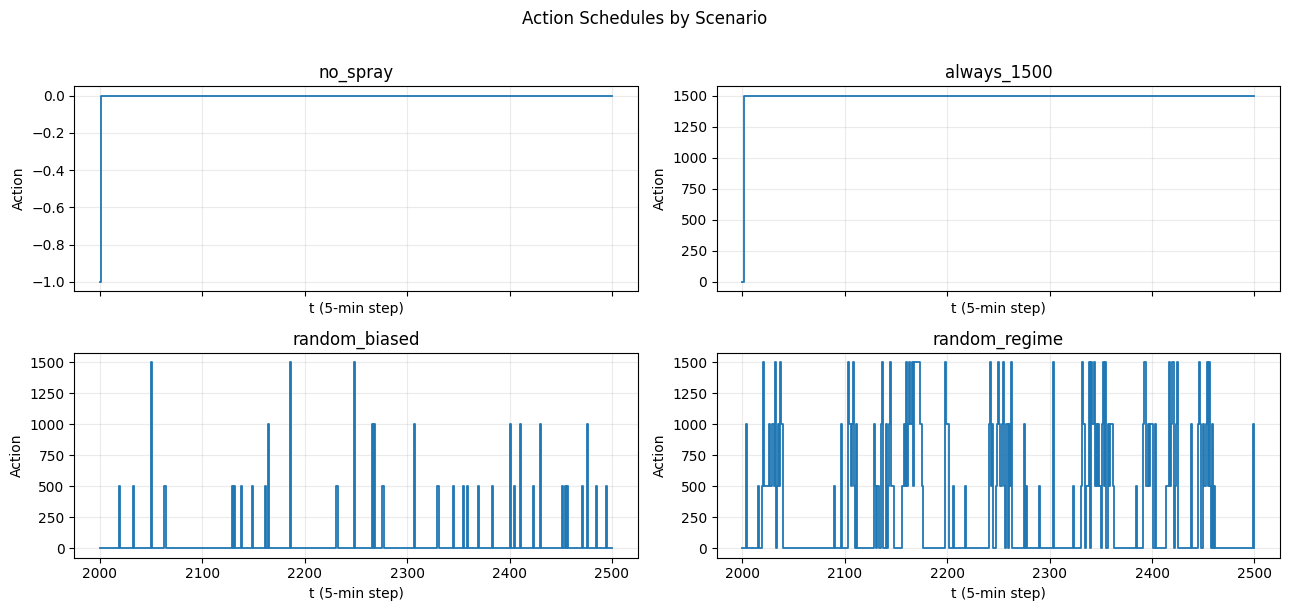

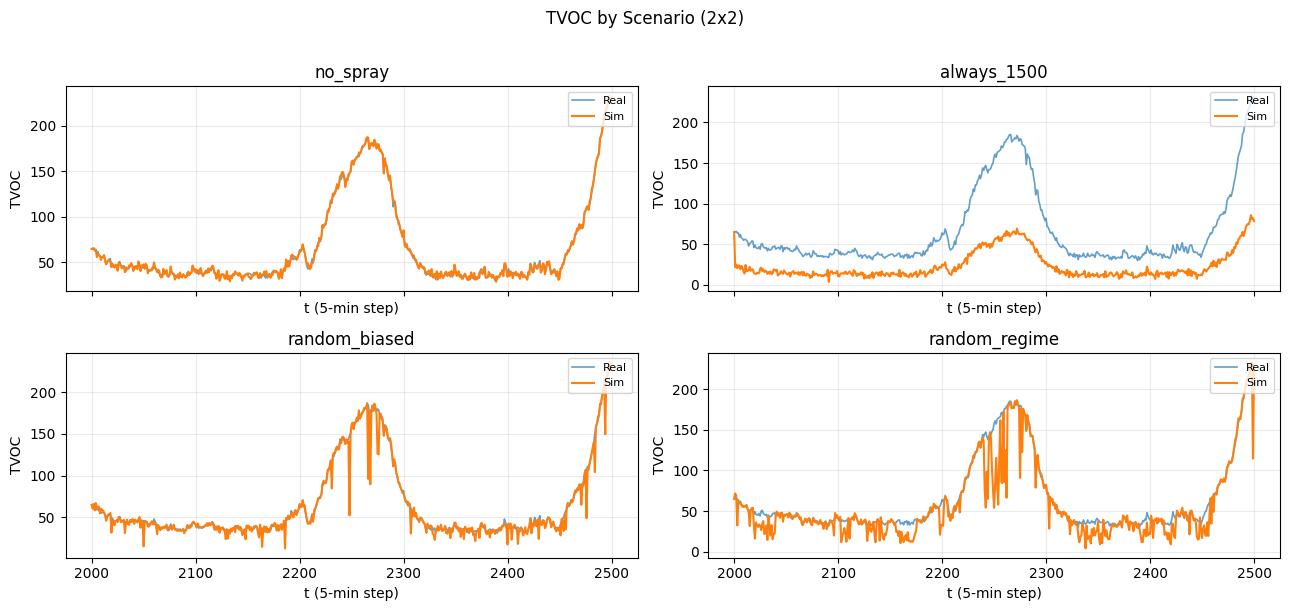

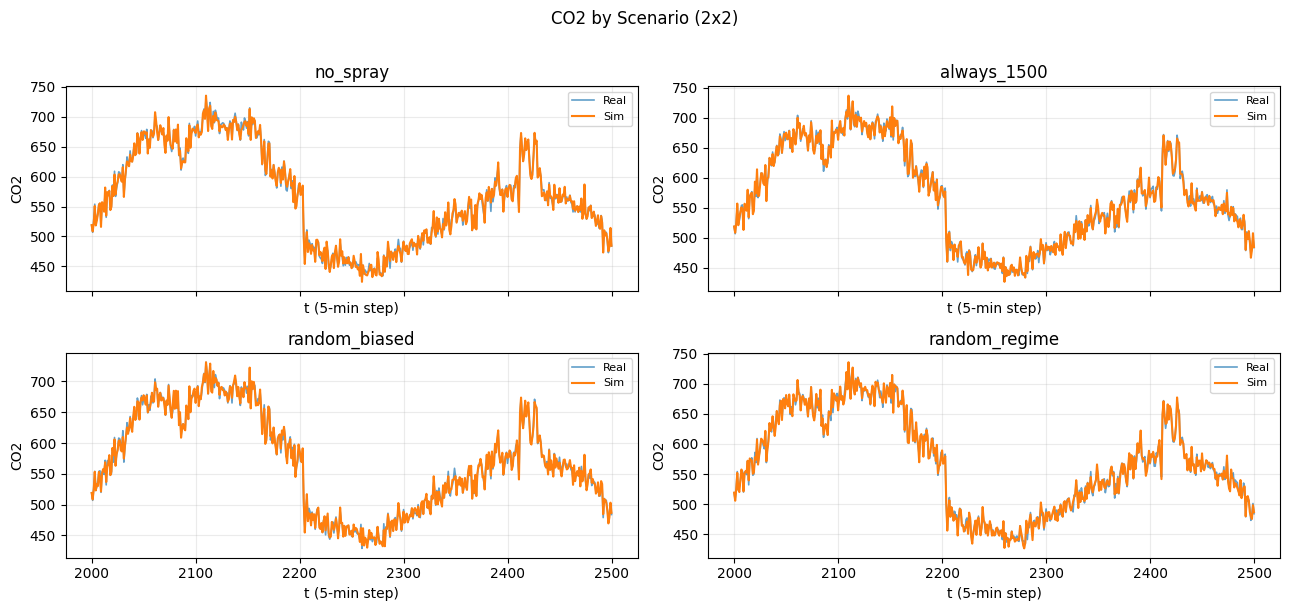

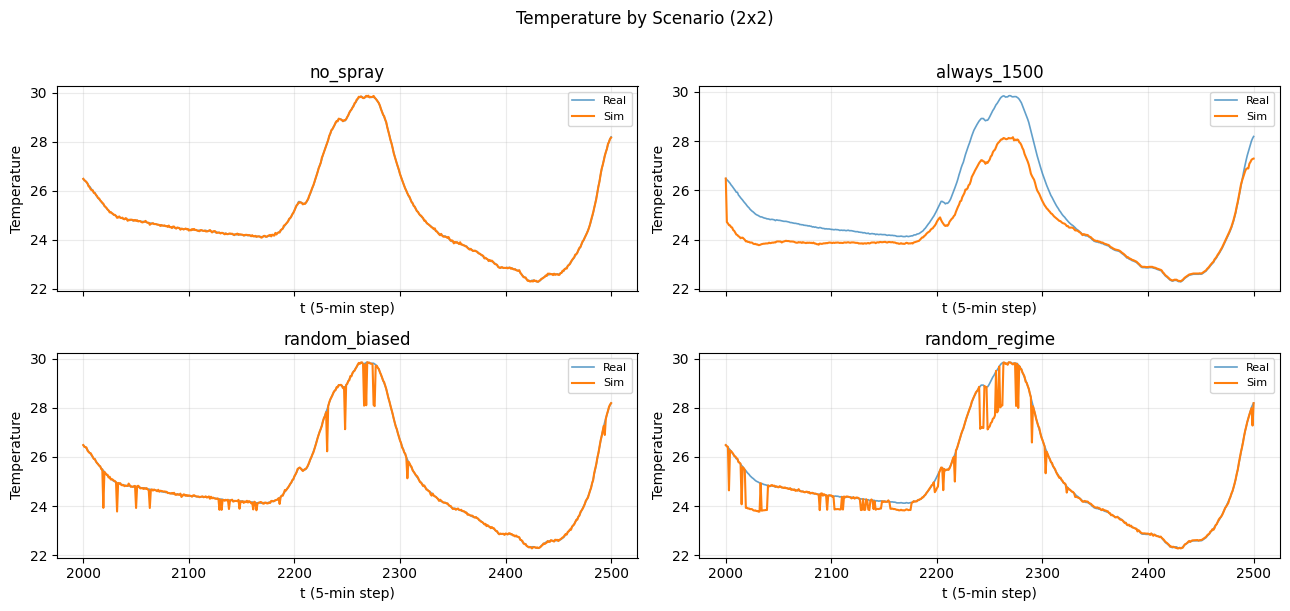

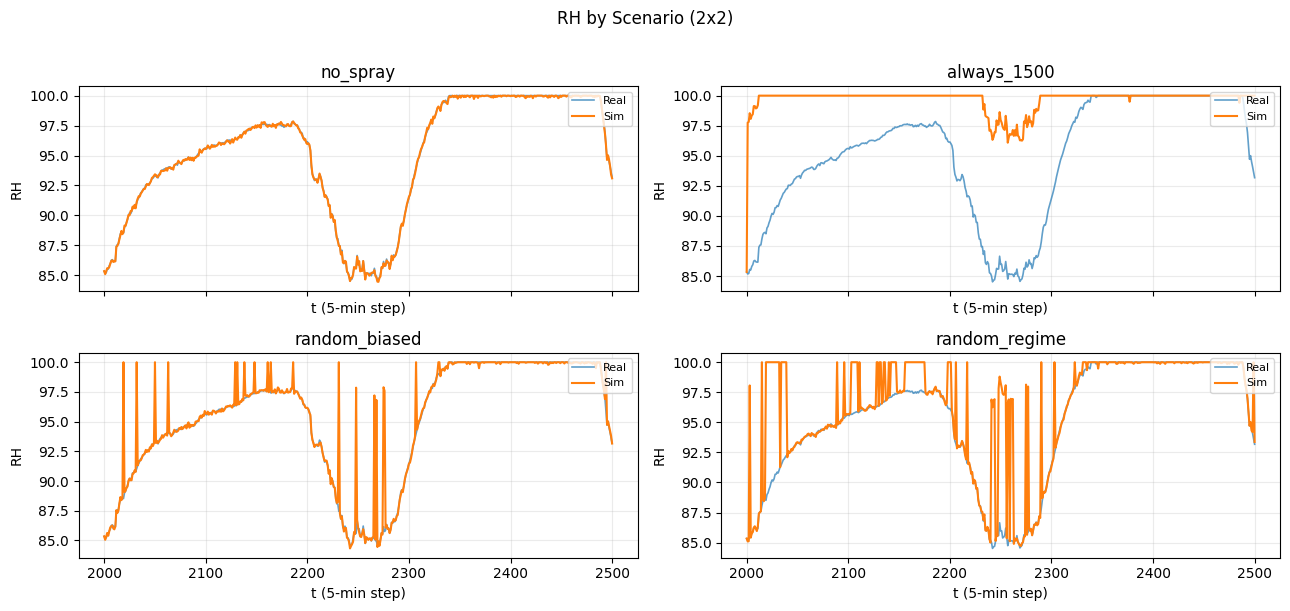

,case,steps,tvoc_start,tvoc_end,tvoc_change,tvoc_mae_vs_real,rh_start,rh_end,rh_change,tvoc_min,tvoc_max
0,no_spray,500,65.0,229.420597,164.420597,1.825912,85.34,93.093279,7.753279,28.760369,231.732630
1,always_1500,500,65.0,78.653589,13.653589,42.862793,85.34,100.000000,14.660000,3.822439,85.877568
2,random_biased,500,65.0,228.456946,163.456946,3.790028,85.34,93.156039,7.816039,12.795315,236.070404
3,random_regime,500,65.0,227.029350,162.029350,9.474661,85.34,93.368333,8.028333,4.062616,232.792023


In [141]:
if "plt" not in globals():
    import matplotlib.pyplot as plt

# Shared simulator/scenario defaults for reproducible quick checks.
SIM_INPUT_FILE = "pi-1-data-clean-5min.csv"
CASE_SUITE: list[str] = ["no_spray", "always_1500", "random_biased", "random_regime"]
CASE_RUN_STEPS = 500
CASE_RUN_T0 = 2000
CASE_RNG_SEED = 17

# Build simulator from pi-1 only.
base_dir = Path.cwd()
if "cleaned_frames" in globals() and "pi-1-data.csv" in cleaned_frames:
    pi1_df = cleaned_frames["pi-1-data.csv"].copy()
else:
    pi1_df = pd.read_csv(base_dir / SIM_INPUT_FILE)

sim = Pi1SpraySimulator(pi1_df)
print(f"Simulator initialized: T={sim.T} steps, action_space={sim.action_space()}")


def _safe_horizon(simulator: Pi1SpraySimulator, requested_steps: int) -> int:
    """Clamp rollout length to available replay horizon."""
    return max(2, min(int(requested_steps), simulator.T - 2))


def make_action_plan(
    case: str,
    steps: int,
    rng: np.random.Generator | None = None,
) -> list[int]:
    """Build categorical action sequence for scenario testing."""
    case_key = case.strip().lower()
    local_rng = rng if rng is not None else np.random.default_rng(CASE_RNG_SEED)

    if case_key in {"no_spray", "none", "case1"}:
        return [0] * steps

    if case_key in {"always_1500", "max", "case2"}:
        return [1500] * steps

    if case_key in {"random_biased", "random", "rare_spray", "case3"}:
        # No spray is dominant; higher concentrations are progressively rarer.
        actions = np.array(ACTION_CONCENTRATIONS, dtype=int)
        probs = np.array([0.90, 0.06, 0.03, 0.01], dtype=float)
        sampled = local_rng.choice(actions, size=steps, replace=True, p=probs)
        return sampled.tolist()

    if case_key in {"random_regime", "regime_switch", "bursty", "case4"}:
        # Regime-switching policy: long sparse periods and occasional bursty periods.
        actions = np.array(ACTION_CONCENTRATIONS, dtype=int)
        low_probs = np.array([0.96, 0.03, 0.009, 0.001], dtype=float)
        high_probs = np.array([0.20, 0.30, 0.30, 0.20], dtype=float)

        # Persistence creates contiguous periods in each regime.
        p_stay_low = 0.97
        p_stay_high = 0.93
        in_high_regime = bool(local_rng.random() < 0.15)

        sampled_actions: list[int] = []
        for _ in range(steps):
            if in_high_regime:
                sampled_actions.append(int(local_rng.choice(actions, p=high_probs)))
                if local_rng.random() > p_stay_high:
                    in_high_regime = False
            else:
                sampled_actions.append(int(local_rng.choice(actions, p=low_probs)))
                if local_rng.random() > p_stay_low:
                    in_high_regime = True

        return sampled_actions

    raise ValueError(
        "Unknown case. Use one of: no_spray, always_1500, random_biased, random_regime."
    )


def run_case(
    simulator: Pi1SpraySimulator,
    case: str,
    steps: int = 300,
    t0: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run one test case and return (simulated, real_reference) DataFrames."""
    safe_steps = _safe_horizon(simulator, steps)
    t0 = int(np.clip(t0, 0, simulator.T - safe_steps - 1))

    actions = make_action_plan(case, safe_steps, rng=simulator.rng)
    sim_df = simulator.rollout(actions, t0=t0).copy()

    real_slice = pd.DataFrame(
        {
            "t": np.arange(t0, t0 + safe_steps + 1),
            "tvoc_real": simulator.real_tvoc[t0 : t0 + safe_steps + 1],
            "co2_real": simulator.real_co2[t0 : t0 + safe_steps + 1],
            "temp_real": simulator.real_temp[t0 : t0 + safe_steps + 1],
            "rh_real": simulator.real_rh[t0 : t0 + safe_steps + 1],
        }
    )

    return sim_df, real_slice


def summarize_case(
    sim_df: pd.DataFrame, real_df: pd.DataFrame, case: str
) -> pd.DataFrame:
    """Compact metrics to support quick tuning iterations."""
    tvoc_start = float(sim_df["tvoc"].iloc[0])
    tvoc_end = float(sim_df["tvoc"].iloc[-1])
    rh_start = float(sim_df["rh"].iloc[0])
    rh_end = float(sim_df["rh"].iloc[-1])

    merged = sim_df.merge(real_df[["t", "tvoc_real"]], on="t", how="left")
    tvoc_mae = float((merged["tvoc"] - merged["tvoc_real"]).abs().mean())

    return pd.DataFrame(
        [
            {
                "case": case,
                "steps": int(len(sim_df) - 1),
                "tvoc_start": tvoc_start,
                "tvoc_end": tvoc_end,
                "tvoc_change": tvoc_end - tvoc_start,
                "tvoc_mae_vs_real": tvoc_mae,
                "rh_start": rh_start,
                "rh_end": rh_end,
                "rh_change": rh_end - rh_start,
                "tvoc_min": float(sim_df["tvoc"].min()),
                "tvoc_max": float(sim_df["tvoc"].max()),
            }
        ]
    )


def _scenario_grid(n_cases: int) -> tuple[int, int]:
    cols = 2
    rows = int(np.ceil(n_cases / cols))
    return rows, cols


def plot_metric_case_grid(
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
    sim_col: str,
    real_col: str,
    y_label: str,
    title: str,
) -> None:
    """Plot one metric across all cases in a compact 2-column grid."""
    cases = list(case_runs.keys())
    rows, cols = _scenario_grid(len(cases))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.0 * rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()

    for i, case in enumerate(cases):
        ax = axes_flat[i]
        sim_df, real_df = case_runs[case]
        ax.plot(real_df["t"], real_df[real_col], label="Real", alpha=0.7, linewidth=1.2)
        ax.plot(sim_df["t"], sim_df[sim_col], label="Sim", linewidth=1.5)
        ax.set_title(case)
        ax.set_ylabel(y_label)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

    for j in range(len(cases), len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[: len(cases)]:
        ax.set_xlabel("t (5-min step)")

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def plot_action_case_grid(
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
) -> None:
    """Plot action schedules across all cases in a compact 2-column grid."""
    cases = list(case_runs.keys())
    rows, cols = _scenario_grid(len(cases))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.0 * rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()

    for i, case in enumerate(cases):
        ax = axes_flat[i]
        sim_df, _ = case_runs[case]
        ax.step(sim_df["t"], sim_df["action"], where="post", linewidth=1.3)
        ax.set_title(case)
        ax.set_ylabel("Action")
        ax.grid(alpha=0.25)

    for j in range(len(cases), len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[: len(cases)]:
        ax.set_xlabel("t (5-min step)")

    fig.suptitle("Action Schedules by Scenario", fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def run_three_case_suite(
    simulator: Pi1SpraySimulator,
    steps: int = 288,
    t0: int = 0,
    plot: bool = True,
) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    """Run case scenarios and return trajectories + summary metrics."""
    trajectories: dict[str, pd.DataFrame] = {}
    summary_frames: list[pd.DataFrame] = []
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {}

    for case in CASE_SUITE:
        sim_df, real_df = run_case(simulator, case=case, steps=steps, t0=t0)
        trajectories[case] = sim_df
        case_runs[case] = (sim_df, real_df)
        summary_frames.append(summarize_case(sim_df, real_df, case))

    if plot:
        plot_action_case_grid(case_runs)

        plot_metric_case_grid(
            case_runs,
            sim_col="tvoc",
            real_col="tvoc_real",
            y_label="TVOC",
            title="TVOC by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="co2",
            real_col="co2_real",
            y_label="CO2",
            title="CO2 by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="temp",
            real_col="temp_real",
            y_label="Temperature",
            title="Temperature by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="rh",
            real_col="rh_real",
            y_label="RH",
            title="RH by Scenario (2x2)",
        )

    summary_df = pd.concat(summary_frames, ignore_index=True)
    return trajectories, summary_df


# Execute default long-horizon checks.
case_trajectories, case_summary_df = run_three_case_suite(
    sim, steps=CASE_RUN_STEPS, t0=CASE_RUN_T0, plot=True
)
case_summary_df

### For tuning reward function normalization constants so term contributions have balanced scales and net the intended significance (scale) in the final reward


In [142]:
def compute_reward_terms(
    simulator: Pi1SpraySimulator,
    state_prev: np.ndarray,
    state_next: np.ndarray,
    action: int,
    t: int,
    reward_weights: RewardWeights | None = None,
) -> dict[str, float]:
    """Compute individual reward terms (not summed) for analysis. No scales applied."""
    w = reward_weights or simulator.cfg.reward
    tvoc_prev, co2_prev, _, _ = state_prev
    tvoc_next, co2_next, temp_next, rh_next = state_next

    safe_tvoc_threshold = w.tvoc_target

    # 1) TVOC (no scale)
    tvoc_delta = tvoc_prev - tvoc_next
    tvoc_progress_term = 0.0
    if w.use_tvoc_delta:
        tvoc_progress_term = np.clip(tvoc_delta / TVOC_PROGRESS_NORM, -2.0, 2.0)
    tvoc_excess = max(0.0, tvoc_next - safe_tvoc_threshold) / TVOC_EXCESS_NORM
    tvoc_excess_term = -tvoc_excess

    # 2) THI (no scale)
    base_t = simulator.real_temp[t] if t < simulator.T - 1 else temp_next
    base_rh = simulator.real_rh[t] if t < simulator.T - 1 else rh_next
    baseline_thi = (0.8 * base_t) + ((base_rh / 100.0) * (base_t - 14.4)) + 46.4
    current_thi = (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4
    safe_thi_threshold = max(73.0, baseline_thi)
    thi_excess = max(0.0, current_thi - safe_thi_threshold) / THI_EXCESS_NORM
    thi_term = -thi_excess

    # 3) RH (no scale)
    rh_excess = max(0.0, rh_next - w.rh_target) / RH_EXCESS_NORM
    rh_term = -rh_excess

    # 4) Cold (no scale)
    safe_temp_min = 18.0
    cold_excess = max(0.0, safe_temp_min - temp_next) / COLD_EXCESS_NORM
    cold_term = -cold_excess

    # 5) Action penalty (no scale, just normalized)
    dose_norm = float(action) / 1500.0
    action_term = -(dose_norm**w.action_curve_power)

    return {
        "tvoc_progress": tvoc_progress_term,
        "tvoc_excess": tvoc_excess_term,
        "thi": thi_term,
        "rh": rh_term,
        "cold": cold_term,
        "action": action_term,
    }


# Analyze reward term balance across scenarios
scenario_term_stats = {}

for case, traj_df in case_trajectories.items():
    term_accum = {
        "tvoc_progress": [],
        "tvoc_excess": [],
        "thi": [],
        "rh": [],
        "cold": [],
        "action": [],
    }

    # Reconstruct states and actions from trajectory
    for idx in range(len(traj_df) - 1):
        t_step = int(traj_df.loc[idx, "t"])
        if t_step >= sim.T - 2:
            break

        state_prev = np.array(
            [
                traj_df.loc[idx, "tvoc"],
                traj_df.loc[idx, "co2"],
                traj_df.loc[idx, "temp"],
                traj_df.loc[idx, "rh"],
            ],
            dtype=float,
        )
        state_next = np.array(
            [
                traj_df.loc[idx + 1, "tvoc"],
                traj_df.loc[idx + 1, "co2"],
                traj_df.loc[idx + 1, "temp"],
                traj_df.loc[idx + 1, "rh"],
            ],
            dtype=float,
        )
        action = int(traj_df.loc[idx + 1, "action"])

        terms = compute_reward_terms(
            sim, state_prev, state_next, action, t_step, sim.cfg.reward
        )
        for term_name, term_val in terms.items():
            term_accum[term_name].append(abs(term_val))

    # Compute stats
    term_stats = {}
    for term_name, vals in term_accum.items():
        if vals:
            term_stats[term_name] = float(np.mean(vals))
        else:
            term_stats[term_name] = 0.0

    scenario_term_stats[case] = term_stats

# Print summary
print("=" * 80)
print("REWARD TERM BALANCE ANALYSIS")
print("=" * 80)

for case, stats in scenario_term_stats.items():
    print(f"\n{case.upper()}:")
    print("  Term                    Mean |Contribution|")
    print("  " + "-" * 45)

    # Sort by magnitude descending
    sorted_terms = sorted(stats.items(), key=lambda x: abs(x[1]), reverse=True)
    max_val = max(abs(v) for v in stats.values()) if stats.values() else 1.0

    for term_name, term_val in sorted_terms:
        ratio_to_max = abs(term_val) / max_val if max_val > 0 else 1.0
        bar_len = int(ratio_to_max * 30)
        bar = "█" * bar_len
        print(f"  {term_name:18s}  {term_val:8.4f}  {bar}")

print("\n" + "=" * 80)


REWARD TERM BALANCE ANALYSIS

NO_SPRAY:
  Term                    Mean |Contribution|
  ---------------------------------------------
  tvoc_excess           1.1576  ██████████████████████████████
  thi                   1.0444  ███████████████████████████
  rh                    0.9108  ███████████████████████
  tvoc_progress         0.7568  ███████████████████
  cold                  0.0000  
  action                0.0000  

ALWAYS_1500:
  Term                    Mean |Contribution|
  ---------------------------------------------
  rh                    1.5505  ██████████████████████████████
  action                1.0000  ███████████████████
  tvoc_progress         0.5709  ███████████
  thi                   0.5689  ███████████
  tvoc_excess           0.0714  █
  cold                  0.0000  

RANDOM_BIASED:
  Term                    Mean |Contribution|
  ---------------------------------------------
  tvoc_excess           1.0954  ██████████████████████████████
  thi             

## 5. RL


### Shared RL setup


In [122]:
from __future__ import annotations

import copy
from dataclasses import dataclass
from typing import Literal

import numpy as np
import pandas as pd
import optuna

from dataclasses import dataclass, field

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize


AlgoName = Literal["ppo", "dqn"]


@dataclass(frozen=True)
class RLRunConfig:
    max_steps: int = 250

    # Hyperparameter search
    tune_trials: int = 20
    tune_budget: int = 50_000
    eval_episodes: int = 20

    # Train/eval scaling
    budgets: tuple[int, ...] = (50_000, 100_000, 200_000)
    n_envs: int = 4
    seed: int = 42

    n_train_seeds: int = 3
    n_eval_seeds: int = 5
    eval_seed_stride: int = 10_000

    # Speed
    use_subproc: bool = False  # set True in a script, usually False in notebooks


RUN_CFG = RLRunConfig()

ALGO_CLASSES = {
    "ppo": PPO,
    "dqn": DQN,
}


@dataclass(frozen=True)
class EnvConfig:
    reward: RewardWeights = field(default_factory=RewardWeights)
    max_steps: int = 250
    gamma: float = 0.99
    tvoc_norm_divisor: float = TVOC_OBS_DIVISOR
    co2_norm_divisor: float = CO2_OBS_DIVISOR
    temp_norm_divisor: float = TEMP_OBS_DIVISOR
    rh_min: float = RH_OBS_MIN
    rh_span: float = RH_OBS_SPAN


# Post-normalization std should be in a similar ballpark across dims.
print("Post-normalization std per observation dimension:")
for name, series, divisor, shift in [
    ("tvoc", _obs_tvoc, TVOC_OBS_DIVISOR, 0.0),
    ("co2", _obs_co2, CO2_OBS_DIVISOR, 0.0),
    ("temp", _obs_temp, TEMP_OBS_DIVISOR, 0.0),
    ("rh", _obs_rh, RH_OBS_SPAN, RH_OBS_MIN),
]:
    normed = (series - shift) / divisor
    print(
        f"  {name:>6s}  std={normed.std():.3f}  min={normed.min():.3f}  max={normed.max():.3f}"
    )


class Pi1SprayEnv(gym.Env):
    """Gymnasium-compliant environment for deodorization spray control."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        simulator: Pi1SpraySimulator,
        config: EnvConfig | None = None,
    ) -> None:
        self.sim = simulator
        self.cfg = config

        # Action space: categorical [0, 500, 1000, 1500]
        self.action_to_concentration = {
            idx: concentration
            for idx, concentration in enumerate(ACTION_CONCENTRATIONS)
        }
        self.action_space = spaces.Discrete(len(self.action_to_concentration))

        # Observation: [tvoc_norm, co2_norm, temp_norm, rh_norm, d_tvoc_norm, d_rh_norm]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 0.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.state: np.ndarray = np.zeros(4, dtype=np.float32)
        self.t: int = 0
        self.steps_taken: int = 0

    def reset(
        self, seed: int | None = None, options: dict | None = None
    ) -> tuple[np.ndarray, dict]:
        super().reset(seed=seed)
        _ = options
        start_t = self.np_random.integers(0, max(1, self.sim.T - self.cfg.max_steps))
        self.t = start_t
        self.state = self.sim.reset(t0=start_t).astype(np.float32)
        self.steps_taken = 0

        obs = self._build_obs(self.state, d_tvoc_norm=0.0, d_rh_norm=0.0)
        return obs, {}

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict]:
        dose = self.action_to_concentration[int(action)]
        state_prev = self.state.copy()
        next_state = self.sim.step(state_prev, dose, self.t).astype(np.float32)

        d_tvoc_norm = float(np.clip((next_state[0] - state_prev[0]) / 500.0, -1.0, 1.0))
        d_rh_norm = float(np.clip((next_state[3] - state_prev[3]) / 60.0, -1.0, 1.0))

        self.state = next_state
        self.t += 1
        self.steps_taken += 1

        terminated = self.t >= self.sim.T - 2
        truncated = self.steps_taken >= self.cfg.max_steps
        is_terminal = terminated or truncated

        reward = self.sim.compute_reward(
            tvoc_prev=float(state_prev[0]),
            tvoc_next=float(next_state[0]),
            co2_prev=float(state_prev[1]),
            co2_next=float(next_state[1]),
            temp_prev=float(state_prev[2]),
            temp_next=float(next_state[2]),
            rh_prev=float(state_prev[3]),
            rh_next=float(next_state[3]),
            action=dose,
            reward_weights=self.cfg.reward,
            is_terminal=is_terminal,
        )

        info = {
            "tvoc": float(self.state[0]),
            "co2": float(self.state[1]),
            "temp": float(self.state[2]),
            "rh": float(self.state[3]),
            "dose": dose,
            "d_tvoc_norm": d_tvoc_norm,
            "d_rh_norm": d_rh_norm,
        }

        obs = self._build_obs(self.state, d_tvoc_norm=d_tvoc_norm, d_rh_norm=d_rh_norm)
        return obs, reward, terminated, truncated, info

    def _build_obs(
        self, s: np.ndarray, d_tvoc_norm: float, d_rh_norm: float
    ) -> np.ndarray:
        base = np.array(
            [
                s[0] / self.cfg.tvoc_norm_divisor,
                s[1] / self.cfg.co2_norm_divisor,
                s[2] / self.cfg.temp_norm_divisor,
                (s[3] - self.cfg.rh_min) / self.cfg.rh_span,
            ],
            dtype=np.float32,
        )
        delta = np.array([d_tvoc_norm, d_rh_norm], dtype=np.float32)
        return np.concatenate([base, delta], axis=0)


Post-normalization std per observation dimension:
    tvoc  std=0.219  min=0.000  max=1.682
     co2  std=0.108  min=0.000  max=1.466
    temp  std=0.080  min=0.622  max=1.090
      rh  std=0.208  min=-0.382  max=1.000


### Environment builders, hyperparameter search, and model construction.


In [123]:
def make_env_cfg(sim, gamma: float) -> EnvConfig:
    return EnvConfig(
        reward=sim.cfg.reward,
        max_steps=RUN_CFG.max_steps,
        gamma=gamma,
    )


def make_env_fn(base_sim, env_cfg: EnvConfig, seed: int, rank: int):
    def _init():
        sim_i = copy.deepcopy(base_sim)
        sim_i.rng = np.random.default_rng(seed + 10_000 * rank)
        env = Pi1SprayEnv(sim_i, config=env_cfg)
        return Monitor(env)

    return _init


def build_vec_env(
    base_sim,
    env_cfg: EnvConfig,
    seed: int,
    n_envs: int,
    normalize: bool = True,
    use_subproc: bool = False,
    gamma: float = 0.99,
):
    vec_cls = SubprocVecEnv if use_subproc else DummyVecEnv
    env_fns = [make_env_fn(base_sim, env_cfg, seed, rank) for rank in range(n_envs)]
    vec_env = vec_cls(env_fns)

    if normalize:
        vec_env = VecNormalize(
            vec_env,
            norm_obs=True,
            norm_reward=True,
            clip_obs=10.0,
            clip_reward=10.0,
            gamma=gamma,
        )
    return vec_env


def sync_vecnormalize(train_env, eval_env):
    # Copy running statistics from training env to eval env.
    eval_env.obs_rms = copy.deepcopy(train_env.obs_rms)
    eval_env.ret_rms = copy.deepcopy(train_env.ret_rms)
    eval_env.training = False
    eval_env.norm_reward = False
    return eval_env


def make_eval_env(base_sim, env_cfg: EnvConfig, train_env, seed: int):
    eval_env = build_vec_env(
        base_sim=base_sim,
        env_cfg=env_cfg,
        seed=seed,
        n_envs=1,
        normalize=True,
        use_subproc=False,
        gamma=env_cfg.gamma,
    )
    return sync_vecnormalize(train_env, eval_env)


def sample_hyperparams(algo: AlgoName, trial: optuna.Trial) -> dict:
    if algo == "ppo":
        # Optune complains about tuples not suitable for persistent storage
        net_arch_str = trial.suggest_categorical(
            "net_arch", ["64,64", "128,128", "256,256"]
        )
        net_arch = tuple(int(x) for x in net_arch_str.split(","))
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 3e-4, log=True),
            "n_steps": trial.suggest_categorical("n_steps", [64, 128, 256]),
            "batch_size": trial.suggest_categorical("batch_size", [64, 128]),
            "n_epochs": trial.suggest_categorical("n_epochs", [5, 10]),
            "gamma": trial.suggest_float("gamma", 0.95, 0.9999),
            "gae_lambda": trial.suggest_float("gae_lambda", 0.90, 0.98),
            "clip_range": trial.suggest_float("clip_range", 0.10, 0.30),
            "ent_coef": trial.suggest_float("ent_coef", 1e-4, 2e-2, log=True),
            "policy_kwargs": {"net_arch": list(net_arch)},
        }

    if algo == "dqn":
        net_arch_str = trial.suggest_categorical(
            "net_arch", ["64,64", "128,128", "256,256"]
        )
        net_arch = tuple(int(x) for x in net_arch_str.split(","))
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
            "buffer_size": trial.suggest_categorical(
                "buffer_size", [50_000, 100_000, 200_000]
            ),
            "learning_starts": trial.suggest_categorical(
                "learning_starts", [1_000, 5_000, 10_000]
            ),
            "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
            "train_freq": trial.suggest_categorical("train_freq", [1, 4]),
            "gradient_steps": trial.suggest_categorical("gradient_steps", [1, 4]),
            "target_update_interval": trial.suggest_categorical(
                "target_update_interval", [250, 500, 1000]
            ),
            "exploration_fraction": trial.suggest_float(
                "exploration_fraction", 0.05, 0.30
            ),
            "exploration_final_eps": trial.suggest_float(
                "exploration_final_eps", 0.01, 0.10
            ),
            "gamma": trial.suggest_float("gamma", 0.95, 0.9999),
            "policy_kwargs": {"net_arch": list(net_arch)},
        }

    raise ValueError(f"Unknown algo: {algo}")


def finalize_params(params: dict) -> dict:
    params = dict(params)
    if "net_arch" in params:
        raw = params.pop("net_arch")
        if isinstance(raw, str):
            net_arch = tuple(int(x) for x in raw.split(","))
        else:
            net_arch = tuple(raw)
        params["policy_kwargs"] = {"net_arch": list(net_arch)}
    return params


def build_model(
    algo: AlgoName,
    train_env,
    params: dict,
    seed: int,
):
    cls = ALGO_CLASSES[algo]
    common = dict(
        policy="MlpPolicy",
        env=train_env,
        seed=seed,
        device="cpu",
        verbose=0,
    )
    return cls(**common, **params)


### Evaluation, tuning, and budget sweep.


In [124]:
def evaluate_model(
    model,
    eval_env,
    env_cfg: EnvConfig,
    n_episodes: int = 20,
    seed: int = 42,
) -> pd.DataFrame:
    reward_list: list[float] = []
    tvoc_delta_list: list[float] = []
    rh_excess_list: list[float] = []
    co2_list: list[float] = []
    temp_list: list[float] = []
    action_counts = {dose: 0 for dose in ACTION_CONCENTRATIONS}
    step_tvoc_hit = 0
    step_co2_hit = 0
    step_count = 0

    for ep in range(n_episodes):
        eval_env.seed(seed + ep)
        obs = eval_env.reset()

        # Raw initial state is stored inside the wrapped env.
        tvoc_start = float(eval_env.get_attr("state")[0][0])

        ep_reward = 0.0
        last_info = None
        done = [False]

        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, rewards, done, infos = eval_env.step(action)

            ep_reward += float(rewards[0])
            info = infos[0]
            last_info = info

            dose = int(info["dose"])
            action_counts[dose] += 1

            tvoc = float(info["tvoc"])
            co2 = float(info["co2"])
            temp = float(info["temp"])
            rh = float(info["rh"])

            tvoc_delta_list.append(tvoc - tvoc_start)
            rh_excess_list.append(max(0.0, rh - env_cfg.reward.rh_target))
            co2_list.append(co2)
            temp_list.append(temp)

            if tvoc <= env_cfg.reward.tvoc_target:
                step_tvoc_hit += 1
            step_count += 1

        reward_list.append(ep_reward)

        if last_info is None:
            continue

    total_actions = max(1, sum(action_counts.values()))
    action_ratio = {
        f"concentration_{dose}_ratio": action_counts[dose] / total_actions
        for dose in ACTION_CONCENTRATIONS
    }
    action_probs = np.array(
        [action_counts[d] / total_actions for d in ACTION_CONCENTRATIONS], dtype=float
    )
    action_entropy = float(
        -(action_probs[action_probs > 0] * np.log(action_probs[action_probs > 0])).sum()
    )
    dominant_action_ratio = float(action_probs.max())

    out = {
        "episodes": n_episodes,
        "reward_mean": float(np.mean(reward_list)),
        "reward_std": float(np.std(reward_list)),
        "tvoc_delta_mean": float(np.mean(tvoc_delta_list))
        if tvoc_delta_list
        else np.nan,
        "tvoc_delta_std": float(np.std(tvoc_delta_list)) if tvoc_delta_list else np.nan,
        "mean_rh_excess": float(np.mean(rh_excess_list)) if rh_excess_list else np.nan,
        "mean_co2": float(np.mean(co2_list)) if co2_list else np.nan,
        "mean_temp": float(np.mean(temp_list)) if temp_list else np.nan,
        "tvoc_target_hit_rate": step_tvoc_hit / max(1, step_count),
        "action_entropy": action_entropy,
        "dominant_action_ratio": dominant_action_ratio,
        **action_ratio,
    }
    return pd.DataFrame([out])


def tune_hyperparams(
    algo: AlgoName,
    base_sim,
    run_cfg: RLRunConfig = RUN_CFG,
) -> dict:
    def objective(trial: optuna.Trial) -> float:
        params = finalize_params(sample_hyperparams(algo, trial))
        gamma = float(params.get("gamma", 0.99))
        env_cfg = make_env_cfg(base_sim, gamma=gamma)

        train_env = build_vec_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            seed=run_cfg.seed + trial.number * 1000,
            n_envs=run_cfg.n_envs,
            normalize=True,
            use_subproc=run_cfg.use_subproc,
            gamma=gamma,
        )
        model = build_model(algo, train_env, params, seed=run_cfg.seed + trial.number)
        model.learn(total_timesteps=run_cfg.tune_budget)

        eval_env = make_eval_env(
            base_sim=base_sim,
            env_cfg=env_cfg,
            train_env=train_env,
            seed=run_cfg.seed + 50_000 + trial.number,
        )
        metrics = evaluate_model(
            model=model,
            eval_env=eval_env,
            env_cfg=env_cfg,
            n_episodes=max(5, run_cfg.eval_episodes // 2),
            seed=run_cfg.seed + 100_000 + trial.number,
        )

        train_env.close()
        eval_env.close()
        return float(metrics.loc[0, "reward_mean"])

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=run_cfg.tune_trials, show_progress_bar=True)
    return finalize_params(study.best_params)


def train_one_budget(
    algo: AlgoName,
    base_sim,
    env_cfg: EnvConfig,
    params: dict,
    total_timesteps: int,
    run_cfg: RLRunConfig = RUN_CFG,
):
    train_env = build_vec_env(
        base_sim=base_sim,
        env_cfg=env_cfg,
        seed=run_cfg.seed,
        n_envs=run_cfg.n_envs,
        normalize=True,
        use_subproc=run_cfg.use_subproc,
        gamma=params.get("gamma", 0.99),
    )
    model = build_model(algo, train_env, params, seed=run_cfg.seed)

    model.learn(total_timesteps=total_timesteps)

    eval_env = make_eval_env(
        base_sim=base_sim,
        env_cfg=env_cfg,
        train_env=train_env,
        seed=run_cfg.seed + 999,
    )
    metrics = evaluate_model(
        model=model,
        eval_env=eval_env,
        env_cfg=env_cfg,
        n_episodes=run_cfg.eval_episodes,
        seed=run_cfg.seed + 1_000,
    )
    metrics.insert(0, "algo", algo)
    metrics["timesteps"] = int(total_timesteps)

    train_env.close()
    eval_env.close()

    return model, metrics

### Run tuning once per algorithm, then sweep multiple budgets.


In [125]:
algorithms_to_run = ("ppo", "dqn")
best_params_by_algo: dict[str, dict] = {}

for algo in algorithms_to_run:
    print(f"\nTuning {algo.upper()} ...")
    best_params = tune_hyperparams(algo, sim, RUN_CFG)
    best_params_by_algo[algo] = best_params
    print(f"Best {algo.upper()} params:\n{best_params}")

print("Summarize of best hyperparameters found:")
for algo, params in best_params_by_algo.items():
    print(f"{algo.upper()}: {params}")

[I 2026-05-09 22:09:20,527] A new study created in memory with name: no-name-273e40f4-1693-4c80-a275-98a11379d29a



Tuning PPO ...


Best trial: 0. Best value: -566.664:   5%|▌         | 1/20 [00:15<04:53, 15.47s/it]

[I 2026-05-09 22:09:35,997] Trial 0 finished with value: -566.6636664967562 and parameters: {'net_arch': '128,128', 'learning_rate': 6.997607201905559e-05, 'n_steps': 64, 'batch_size': 64, 'n_epochs': 10, 'gamma': 0.9941373043345337, 'gae_lambda': 0.9094281890843463, 'clip_range': 0.2160766720500789, 'ent_coef': 0.00030057107717804815}. Best is trial 0 with value: -566.6636664967562.


Best trial: 0. Best value: -566.664:  10%|█         | 2/20 [00:26<03:47, 12.66s/it]

...

[I 2026-05-09 22:17:32,245] Trial 17 finished with value: -655.271010243916 and parameters: {'net_arch': '256,256', 'learning_rate': 0.00044301583283572475, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 64, 'train_freq': 4, 'gradient_steps': 4, 'target_update_interval': 1000, 'exploration_fraction': 0.0822342502126564, 'exploration_final_eps': 0.05239514454471396, 'gamma': 0.9622823901801411}. Best is trial 9 with value: -288.4497837706149.


Best trial: 9. Best value: -288.45:  95%|█████████▌| 19/20 [05:14<00:20, 20.64s/it]

[I 2026-05-09 22:18:09,121] Trial 18 finished with value: -666.4154356419501 and parameters: {'net_arch': '256,256', 'learning_rate': 2.1932543568428915e-05, 'buffer_size': 50000, 'learning_starts': 10000, 'batch_size': 64, 'train_freq': 1, 'gradient_steps': 4, 'target_update_interval': 250, 'exploration_fraction': 0.20259071406350546, 'exploration_final_eps': 0.03038031332301526, 'gamma': 0.9715233972366101}. Best is trial 9 with value: -288.4497837706149.


Best trial: 9. Best value: -288.45: 100%|██████████| 20/20 [05:27<00:00, 16.35s/it]

[I 2026-05-09 22:18:22,108] Trial 19 finished with value: -674.7173838154835 and parameters: {'net_arch': '128,128', 'learning_rate': 0.00010001660368254208, 'buffer_size': 200000, 'learning_starts': 1000, 'batch_size': 32, 'train_freq': 4, 'gradient_steps': 4, 'target_update_interval': 500, 'exploration_fraction': 0.1121174665694429, 'exploration_final_eps': 0.09719280409119749, 'gamma': 0.9807366954173415}. Best is trial 9 with value: -288.4497837706149.
Best DQN params:
{'learning_rate': 0.0005674794889964773, 'buffer_size': 50000, 'learning_starts': 10000, 'batch_size': 64, 'train_freq': 4, 'gradient_steps': 4, 'target_update_interval': 1000, 'exploration_fraction': 0.10546968932630109, 'exploration_final_eps': 0.0627298012502866, 'gamma': 0.9700302774481009, 'policy_kwargs': {'net_arch': [256, 256]}}
Summarize of best hyperparameters found:
PPO: {'learning_rate': 1.1328708407493516e-05, 'n_steps': 256, 'batch_size': 128, 'n_epochs': 5, 'gamma': 0.9511924482348246, 'gae_lambda': 0.

In [126]:
all_rows: list[pd.DataFrame] = []

for algo in algorithms_to_run:
    best_params = best_params_by_algo[algo]
    gamma = float(best_params.get("gamma", 0.99))
    env_cfg = make_env_cfg(sim, gamma=gamma)

    for budget in RUN_CFG.budgets:
        print(f"\nTraining {algo.upper()} for {budget:,} timesteps ...")
        _, metrics = train_one_budget(
            algo=algo,
            base_sim=sim,
            env_cfg=env_cfg,
            params=best_params,
            total_timesteps=budget,
            run_cfg=RUN_CFG,
        )
        metrics.insert(0, "gamma", gamma)
        all_rows.append(metrics)
        print(metrics.to_string(index=False))

results_df = pd.concat(all_rows, ignore_index=True)
results_df = results_df.sort_values(["algo", "timesteps"]).reset_index(drop=True)
results_df


Training PPO for 50,000 timesteps ...
   gamma algo  episodes  reward_mean  reward_std  tvoc_delta_mean  tvoc_delta_std  mean_rh_excess   mean_co2  mean_temp  tvoc_target_hit_rate  action_entropy  dominant_action_ratio  concentration_0_ratio  concentration_500_ratio  concentration_1000_ratio  concentration_1500_ratio  timesteps
0.951192  ppo        20  -383.187964  160.176692       -56.578023       67.615885        7.375222 539.850044  26.234476                 0.335        0.980429                 0.6028                  0.008                   0.6028                     0.203                    0.1862      50000

Training PPO for 100,000 timesteps ...
   gamma algo  episodes  reward_mean  reward_std  tvoc_delta_mean  tvoc_delta_std  mean_rh_excess   mean_co2  mean_temp  tvoc_target_hit_rate  action_entropy  dominant_action_ratio  concentration_0_ratio  concentration_500_ratio  concentration_1000_ratio  concentration_1500_ratio  timesteps
0.951192  ppo        20  -386.604996  178.541

,gamma,algo,episodes,reward_mean,reward_std,tvoc_delta_mean,tvoc_delta_std,mean_rh_excess,mean_co2,mean_temp,tvoc_target_hit_rate,action_entropy,dominant_action_ratio,concentration_0_ratio,concentration_500_ratio,concentration_1000_ratio,concentration_1500_ratio,timesteps
0,0.970030,dqn,20,-405.994543,104.185065,-72.611743,63.514318,7.392359,539.850044,26.226075,0.5840,0.920144,0.4974,0.0052,0.0678,0.4296,0.4974,50000
1,0.970030,dqn,20,-424.522536,123.993407,-71.191825,65.865781,7.386218,539.850044,26.232006,0.5832,0.811815,0.5330,0.0088,0.0184,0.5330,0.4398,100000
2,0.970030,dqn,20,-410.234164,106.400580,-73.163406,63.842495,7.280048,539.850044,26.240080,0.5940,0.838994,0.5060,0.0306,0.0058,0.4576,0.5060,200000
3,0.951192,ppo,20,-383.187964,160.176692,-56.578023,67.615885,7.375222,539.850044,26.234476,0.3350,0.980429,0.6028,0.0080,0.6028,0.2030,0.1862,50000
4,0.951192,ppo,20,-386.604996,178.541141,-60.015193,66.706605,7.331079,539.850044,26.236127,0.3402,1.008096,0.5624,0.0124,0.5624,0.1358,0.2894,100000
5,0.951192,ppo,20,-366.915632,106.975992,-71.164552,63.917284,7.425725,539.850044,26.221820,0.5012,1.057755,0.4566,0.0000,0.2244,0.3190,0.4566,200000


## 7. Demo Code for Online Update Loop with Real Data Feed

Only for showing what it would look like to adapt this approach to when real data will be available. By then, the agent and Gym environment will continuously collect transitions and periodically continue training.

Caution: this loop runs indefinitely (`while True`), and is not intended to be run per the above description.
